# Actividad 3: Mapas Estroboscopicos

Número de órbitas: 525
Integración terminada en 58.1 s


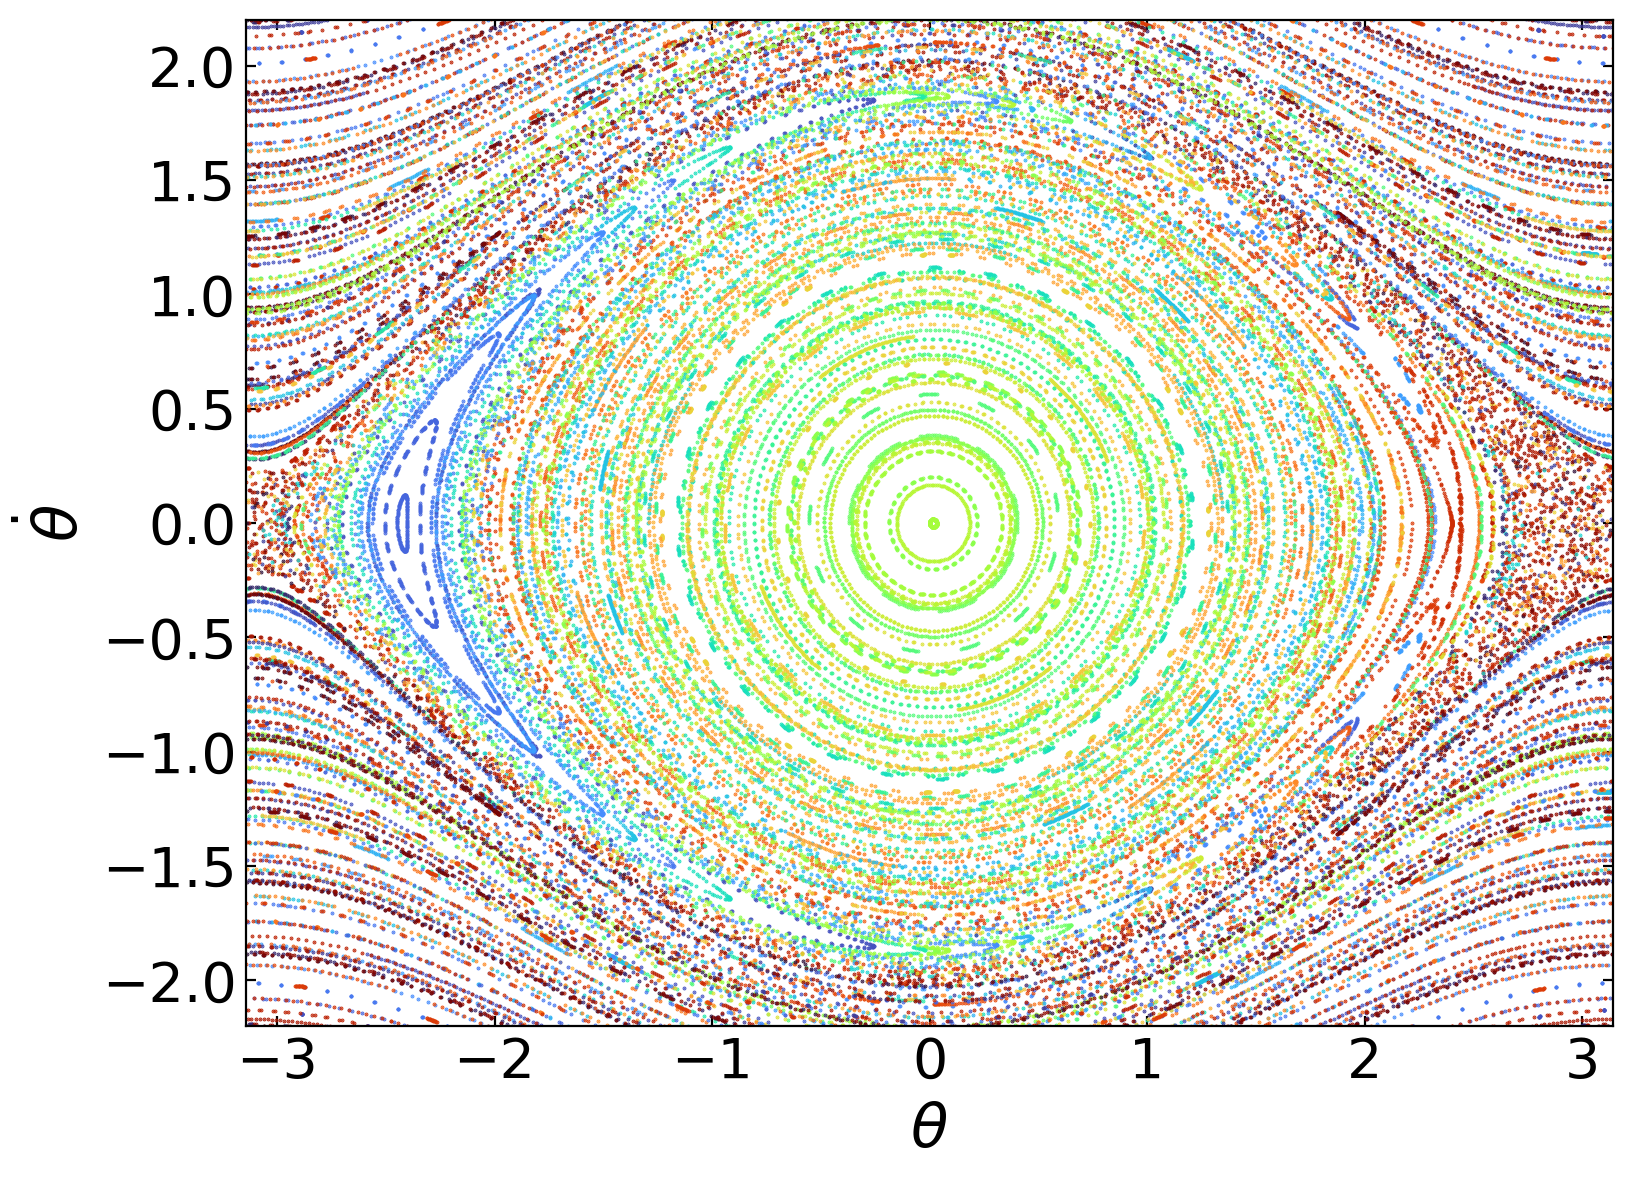

¡Imagen PNG guardada con éxito!


In [17]:
import numpy as np
from numpy import sin, cos, pi
import matplotlib.pyplot as plt
import time

# -----------------------------------------------------------
# System parameters
# -----------------------------------------------------------
ml = 1.0
g_l = 1.0
F0 = 0.01
omega = 2.0 / pi

T = 2 * pi / omega         # Periodo de la fuerza externa

# -----------------------------------------------------------
# Initial conditions (Grid / Barrido para el mapa)
# -----------------------------------------------------------
theta0_list = np.linspace(-3.14, 3.14, 35)
theta_dot0_list = np.linspace(-2.2, 2.2, 15)

TH0, THD0 = np.meshgrid(theta0_list, theta_dot0_list)
theta0_flat = TH0.ravel()
theta_dot0_flat = THD0.ravel()
n_orbitas = len(theta0_flat)
print(f"Número de órbitas: {n_orbitas}")

# Estado inicial combinado para todas las órbitas en paralelo
y0 = np.concatenate([theta0_flat, theta_dot0_flat])

# -----------------------------------------------------------
# Method parameters
# -----------------------------------------------------------
N_PERIODOS = 150
tmax = N_PERIODOS * T
dt = 0.001  # Ajustado a un valor óptimo y rápido para RK4

# -----------------------------------------------------------
# Dynamics: Forced pendulum (Vectorized)
# -----------------------------------------------------------
def dyn(t, y):
    theta = y[:n_orbitas]
    theta_dot = y[n_orbitas:]
    dx = theta_dot
    dv = -g_l * sin(theta) + (F0 / ml) * cos(omega * t)
    return np.concatenate([dx, dv])

# -----------------------------------------------------------
# Fourth-order Runge-Kutta method
# -----------------------------------------------------------
def rk4(f, t, y, h):
    k1 = h * f(t, y)
    k2 = h * f(t + h/2, y + k1/2)
    k3 = h * f(t + h/2, y + k2/2)
    k4 = h * f(t + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

# -----------------------------------------------------------
# Integration using RK4 and Stroboscopic Sampling
# -----------------------------------------------------------
n_steps = int(tmax / dt)
t = 0.0
y = y0.copy()

strobe_theta = []
strobe_theta_dot = []

next_strobe_t = 0.0
t0 = time.time()

for i in range(n_steps):
    # Capturar puntos estroboscópicos cada período T
    if abs(t - next_strobe_t) < dt / 2:
        th = y[:n_orbitas]
        th_dot = y[n_orbitas:]
        # Módulo para acotar theta en [-pi, pi]
        th_mod = (th + pi) % (2 * pi) - pi
        strobe_theta.append(th_mod.copy())
        strobe_theta_dot.append(th_dot.copy())
        next_strobe_t += T
        
    y = rk4(dyn, t, y, dt)
    t += dt

print(f"Integración terminada en {time.time()-t0:.1f} s")

strobe_theta = np.array(strobe_theta)
strobe_theta_dot = np.array(strobe_theta_dot)

# -----------------------------------------------------------
# Phase space / Stroboscopic Map
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

# Mapa de colores basado en la posición inicial para mantener simetría visual
norm_colors = (theta0_flat - theta0_flat.min()) / (theta0_flat.max() - theta0_flat.min())
colors = plt.cm.turbo(norm_colors)

for i in range(n_orbitas):
    ax.plot(strobe_theta[:, i], strobe_theta_dot[:, i], '.', 
            color=colors[i], markersize=0.8, alpha=0.9)

ax.set_xlabel(r'$\theta$', fontsize=22)
ax.set_ylabel(r'$\dot{\theta}$', fontsize=22)
ax.tick_params(axis='both', labelsize=20, direction='in', top=True, right=True)
ax.set_xlim(-pi, pi)
ax.set_ylim(-2.2, 2.2)

plt.tight_layout()

# CAMBIO CLAVE: Extensión .png para asegurar que guarde una imagen
plt.savefig("mapa_estroboscopico.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
print("¡Imagen PNG guardada con éxito!")